In [1]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#### NHANES

In [2]:
#import dataframe output from table 1
df = pd.read_csv(r"Z:\Output\Data tables\EyeFields3.csv")
df = df[['SEQN', 'RetLev']]

In [3]:
print('N of Respondents with DR grading: ', df['SEQN'].nunique())
df.shape

N of Respondents with DR grading:  5828


(5828, 2)

In [4]:
df.isna().sum()

SEQN       0
RetLev    85
dtype: int64

In [5]:
df['RetLev'].value_counts()

0.0    4994
1.0     454
2.0     213
5.0      39
4.0      31
3.0      12
Name: RetLev, dtype: int64

#### Model A

In [6]:
#import A_output
a = pd.read_csv(r"Z:\Data\A_output_upd.csv")
a = a[['SEQN','Laterality', 'Retinopathy']]
a = a.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
#merge NHANES and A model
a = pd.merge(df, a, on='SEQN')
print('N in NHANES and Model A: ', a['SEQN'].nunique())

N in NHANES and Model A:  5827


In [7]:
#take worse eye prediction
a['Worse'] = a[['OD', 'OS']].max(axis=1)

In [8]:
a = a[['SEQN','RetLev', 'Worse']]

In [9]:
a.isna().sum()

SEQN       0
RetLev    85
Worse      0
dtype: int64

In [10]:
#drop all na rows
a = a.dropna(subset=['RetLev'], how = 'all')

In [11]:
actual = a['RetLev']
predicted = a['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

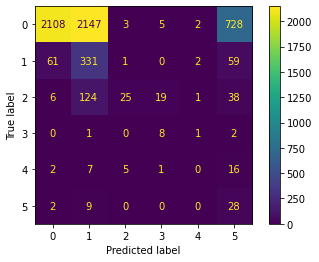

In [12]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [13]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.97      0.42      0.59      4993
         1.0       0.13      0.73      0.22       454
         2.0       0.74      0.12      0.20       213
         3.0       0.24      0.67      0.36        12
         4.0       0.00      0.00      0.00        31
         5.0       0.03      0.72      0.06        39

    accuracy                           0.44      5742
   macro avg       0.35      0.44      0.24      5742
weighted avg       0.88      0.44      0.54      5742



#### Model B

In [14]:
#import B_output
b = pd.read_csv(r"Z:\Data\output-B_upd.csv")
b = b[['SEQN','Laterality', 'Retinopathy']]
b = b.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
b = pd.merge(df, b, on='SEQN')
print('N in NHANES and Model B: ', b['SEQN'].nunique())

N in NHANES and Model B:  5827


In [15]:
b['Worse'] = b[['OD', 'OS']].max(axis=1)

In [16]:
b = b[['SEQN','RetLev', 'Worse']]

In [17]:
b.isna().sum()

SEQN       0
RetLev    85
Worse      0
dtype: int64

In [18]:
b = b.dropna(subset=['RetLev'], how = 'all')

In [19]:
b['SEQN'].nunique()

5742

In [20]:
actual = b['RetLev']
predicted = b['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

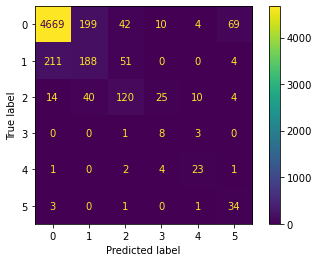

In [21]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [22]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94      4993
         1.0       0.44      0.41      0.43       454
         2.0       0.55      0.56      0.56       213
         3.0       0.17      0.67      0.27        12
         4.0       0.56      0.74      0.64        31
         5.0       0.30      0.87      0.45        39

    accuracy                           0.88      5742
   macro avg       0.50      0.70      0.55      5742
weighted avg       0.89      0.88      0.88      5742



#### Model C - note - model C included 2 values for some samples so selected the worse score (so if the rating was a o and a 4, selected the 4)

In [23]:
#import C_output
c = pd.read_csv(r"Z:\Data\C_Results_upd.csv")
c = c[['SEQN','Laterality', 'DR Scale']]
c.shape

(25750, 3)

In [24]:
c= c.sort_values('DR Scale', ascending = False).drop_duplicates('SEQN')

In [25]:
c = c.pivot(index = 'SEQN', columns = 'Laterality', values = 'DR Scale')
c = pd.merge(df, c, on='SEQN')
print('N in NHANES and Model C: ', c['SEQN'].nunique())

N in NHANES and Model C:  5827


In [26]:
c['Worse'] = c[['OD', 'OS']].max(axis=1)
c = c[['SEQN','RetLev', 'Worse']]

In [27]:
c.isna().sum()

SEQN       0
RetLev    85
Worse      0
dtype: int64

In [28]:
c = c.dropna(subset=['RetLev'], how = 'all')

In [29]:
c['SEQN'].nunique()

5742

In [30]:
actual = c['RetLev']
predicted = c['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

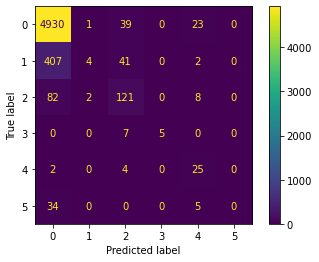

In [31]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [32]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94      4993
         1.0       0.57      0.01      0.02       454
         2.0       0.57      0.57      0.57       213
         3.0       1.00      0.42      0.59        12
         4.0       0.40      0.81      0.53        31
         5.0       0.00      0.00      0.00        39

    accuracy                           0.89      5742
   macro avg       0.57      0.46      0.44      5742
weighted avg       0.86      0.89      0.85      5742



#### Model D

In [33]:
#import D_output
d = pd.read_csv(r"Z:\Data\output-D_upd.csv")
d = d[['SEQN','Laterality', 'Retinopathy']]
d = d.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
d = pd.merge(df, d, on='SEQN')
print('N in NHANES and Model D: ', d['SEQN'].nunique())

N in NHANES and Model D:  5183


In [34]:
d['Worse'] = d[['OD', 'OS']].max(axis=1)

In [35]:
d = d[['SEQN','RetLev', 'Worse']]

In [36]:
d.isna().sum()

SEQN       0
RetLev    48
Worse      0
dtype: int64

In [37]:
d = d.dropna(subset=['RetLev'], how = 'all')

In [38]:
d['SEQN'].nunique()

5135

In [39]:
actual = d['RetLev']
predicted = d['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

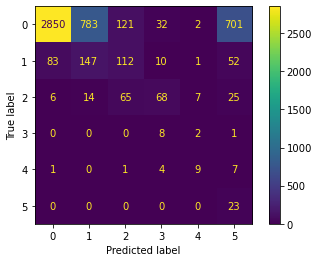

In [40]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [41]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.97      0.63      0.77      4489
         1.0       0.16      0.36      0.22       405
         2.0       0.22      0.35      0.27       185
         3.0       0.07      0.73      0.12        11
         4.0       0.43      0.41      0.42        22
         5.0       0.03      1.00      0.06        23

    accuracy                           0.60      5135
   macro avg       0.31      0.58      0.31      5135
weighted avg       0.87      0.60      0.70      5135



#### Model E

In [42]:
#import E_output
e = pd.read_csv(r"Z:\Data\output-E_upd.csv")
e = e[['SEQN','Laterality', 'Retinopathy']]
e = e.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
e = pd.merge(df, e, on='SEQN')
print('N in NHANES and Model E: ', e['SEQN'].nunique())

N in NHANES and Model E:  5183


In [43]:
e['Worse'] = e[['OD', 'OS']].max(axis=1)

In [44]:
e = e[['SEQN','RetLev', 'Worse']]

In [45]:
e.isna().sum()

SEQN       0
RetLev    48
Worse      0
dtype: int64

In [46]:
e = e.dropna(subset=['RetLev'], how = 'all')
e['SEQN'].nunique()

5135

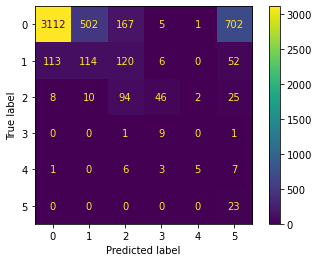

In [47]:
actual = e['RetLev']
predicted = e['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [48]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.96      0.69      0.81      4489
         1.0       0.18      0.28      0.22       405
         2.0       0.24      0.51      0.33       185
         3.0       0.13      0.82      0.23        11
         4.0       0.62      0.23      0.33        22
         5.0       0.03      1.00      0.06        23

    accuracy                           0.65      5135
   macro avg       0.36      0.59      0.33      5135
weighted avg       0.87      0.65      0.74      5135



#### Model F

In [49]:
#import F_output
f = pd.read_csv(r"Z:\Data\output-F_upd.csv")
f = f[['SEQN','Laterality', 'Retinopathy']]
f = f.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
f = pd.merge(df, f, on='SEQN')
print('N in NHANES and Model F: ', f['SEQN'].nunique())

N in NHANES and Model F:  5827


In [50]:
f['Worse'] = f[['OD', 'OS']].max(axis=1)
f = f[['SEQN','RetLev', 'Worse']]

In [51]:
f.isna().sum()

SEQN       0
RetLev    85
Worse      2
dtype: int64

In [52]:
f = f.dropna()
f['SEQN'].nunique()

5740

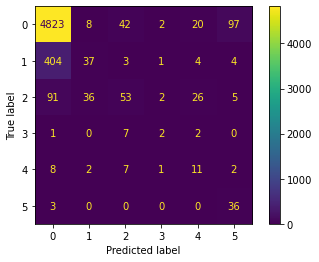

In [53]:
actual = f['RetLev']
predicted = f['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [54]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      4992
         1.0       0.45      0.08      0.14       453
         2.0       0.47      0.25      0.33       213
         3.0       0.25      0.17      0.20        12
         4.0       0.17      0.35      0.23        31
         5.0       0.25      0.92      0.39        39

    accuracy                           0.86      5740
   macro avg       0.42      0.46      0.37      5740
weighted avg       0.84      0.86      0.84      5740



#### Model G

In [55]:
#import G_output
g = pd.read_csv(r"Z:\Data\output - G_upd.csv")
g = g[['SEQN','Laterality', 'Retinopathy']]
g = g.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
g = pd.merge(df, g, on='SEQN')
print('N in NHANES and Model G: ', g['SEQN'].nunique())

N in NHANES and Model G:  5827


In [56]:
g['Worse'] = g[['OD', 'OS']].max(axis=1)
g = g[['SEQN','RetLev', 'Worse']]

In [57]:
g.isna().sum()

SEQN       0
RetLev    85
Worse      0
dtype: int64

In [58]:
g = g.dropna()
g['SEQN'].nunique()

5742

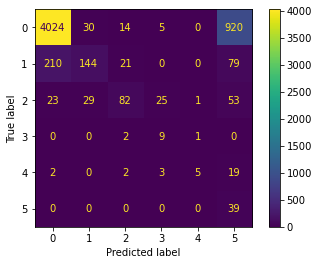

In [59]:
actual = g['RetLev']
predicted = g['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [60]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.94      0.81      0.87      4993
         1.0       0.71      0.32      0.44       454
         2.0       0.68      0.38      0.49       213
         3.0       0.21      0.75      0.33        12
         4.0       0.71      0.16      0.26        31
         5.0       0.04      1.00      0.07        39

    accuracy                           0.75      5742
   macro avg       0.55      0.57      0.41      5742
weighted avg       0.91      0.75      0.81      5742



#### Model H

In [61]:
#import H_output
h = pd.read_csv(r"Z:\Data\output-H_upd.csv")
h = h[['SEQN','Laterality', 'Retinopathy']]
h = h.pivot(index = 'SEQN', columns = 'Laterality', values = 'Retinopathy')
h = pd.merge(df, h, on='SEQN')
print('N in NHANES and Model H: ', h['SEQN'].nunique())

N in NHANES and Model H:  5827


In [62]:
h['Worse'] = h[['OD', 'OS']].max(axis=1)
h = h[['SEQN','RetLev', 'Worse']]

In [63]:
h.isna().sum()

SEQN       0
RetLev    85
Worse      0
dtype: int64

In [64]:
h = h.dropna()
h['SEQN'].nunique()

5742

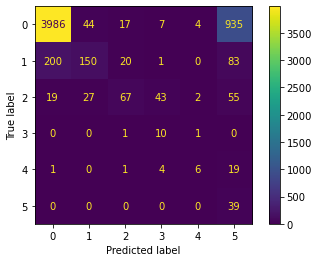

In [65]:
actual = h['RetLev']
predicted = h['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [66]:
 from sklearn.metrics import classification_report
 print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.95      0.80      0.87      4993
         1.0       0.68      0.33      0.44       454
         2.0       0.63      0.31      0.42       213
         3.0       0.15      0.83      0.26        12
         4.0       0.46      0.19      0.27        31
         5.0       0.03      1.00      0.07        39

    accuracy                           0.74      5742
   macro avg       0.48      0.58      0.39      5742
weighted avg       0.90      0.74      0.81      5742



#### ROC
*for models a,b,f,g,h

In [98]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [104]:
prob_a = pd.read_csv(r"Z:\Data\A_prob_upd.csv")
prob_b = pd.read_csv(r"Z:\Data\probs-B_upd.csv")
prob_f = pd.read_csv(r"Z:\Data\prob-F_upd.csv")
prob_g = pd.read_csv(r"Z:\Data\prob - G_upd.csv")
prob_h = pd.read_csv(r"Z:\Data\prob-H_upd.csv")

##### no Ret prob

In [93]:
prob_a = prob_a[['SEQN','Laterality', 'No_DR_prob']]
prob_a = prob_a.pivot(index = 'SEQN', columns = 'Laterality', values = 'No_DR_prob')
prob_a = pd.merge(df, prob_a, on='SEQN')

prob_b = prob_b[['SEQN','Laterality', 'No_DR_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'No_DR_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')

prob_f = prob_f[['SEQN','Laterality', 'No_DR_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'No_DR_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')

prob_g = prob_g[['SEQN','Laterality', 'No_DR_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'No_DR_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')

prob_h = prob_h[['SEQN','Laterality', 'No_DR_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'No_DR_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')

In [94]:
prob_a['Worse'] = prob_a[['OD', 'OS']].max(axis=1)
prob_a = prob_a[['SEQN','RetLev', 'Worse']]

prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','RetLev', 'Worse']]

prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','RetLev', 'Worse']]

prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','RetLev', 'Worse']]

prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','RetLev', 'Worse']]

In [95]:
prob_a = prob_a.dropna()
prob_b = prob_b.dropna()
prob_f = prob_f.dropna()
prob_g = prob_g.dropna()
prob_h = prob_h.dropna()

print ("N_A: ", prob_a['SEQN'].nunique())
print ("N_B: ", prob_b['SEQN'].nunique())
print ("N_F: ", prob_f['SEQN'].nunique())
print ("N_G: ", prob_g['SEQN'].nunique())
print ("N_H: ", prob_h['SEQN'].nunique())

N_A:  5378
N_B:  5716
N_F:  5699
N_G:  5742
N_H:  5742


In [100]:
actual = prob_a['RetLev']
predicted = prob_a['Worse']
a_fpr, a_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=0)

actual = prob_b['RetLev']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=0)

actual = prob_f['RetLev']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=0)

actual = prob_g['RetLev']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=0)

actual = prob_h['RetLev']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=0)

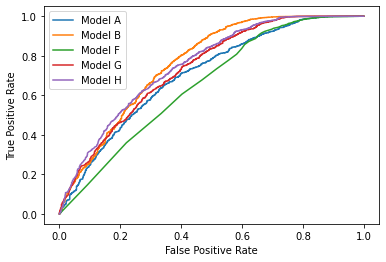

In [101]:
pyplot.plot(a_fpr, a_tpr, label='Model A')
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [102]:
plt.savefig(r"Z:\Output\Data tables\ROC\No_DR.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>

#### Mild NPR

In [105]:
prob_a = prob_a[['SEQN','Laterality', 'Mild_NPDR_prob']]
prob_a = prob_a.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mild_NPDR_prob')
prob_a = pd.merge(df, prob_a, on='SEQN')

prob_b = prob_b[['SEQN','Laterality', 'Mild_NPDR_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mild_NPDR_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')

prob_f = prob_f[['SEQN','Laterality', 'Mild_NPDR_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mild_NPDR_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')

prob_g = prob_g[['SEQN','Laterality', 'Mild_NPDR_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mild_NPDR_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')

prob_h = prob_h[['SEQN','Laterality', 'Mild_NPDR_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mild_NPDR_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')

In [106]:
prob_a['Worse'] = prob_a[['OD', 'OS']].max(axis=1)
prob_a = prob_a[['SEQN','RetLev', 'Worse']]

prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','RetLev', 'Worse']]

prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','RetLev', 'Worse']]

prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','RetLev', 'Worse']]

prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','RetLev', 'Worse']]

In [107]:
prob_a = prob_a.dropna()
prob_b = prob_b.dropna()
prob_f = prob_f.dropna()
prob_g = prob_g.dropna()
prob_h = prob_h.dropna()

print ("N_A: ", prob_a['SEQN'].nunique())
print ("N_B: ", prob_b['SEQN'].nunique())
print ("N_F: ", prob_f['SEQN'].nunique())
print ("N_G: ", prob_g['SEQN'].nunique())
print ("N_H: ", prob_h['SEQN'].nunique())

N_A:  5378
N_B:  5716
N_F:  5699
N_G:  5742
N_H:  5742


In [109]:
actual = prob_a['RetLev']
predicted = prob_a['Worse']
a_fpr, a_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

actual = prob_b['RetLev']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

actual = prob_f['RetLev']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

actual = prob_g['RetLev']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

actual = prob_h['RetLev']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

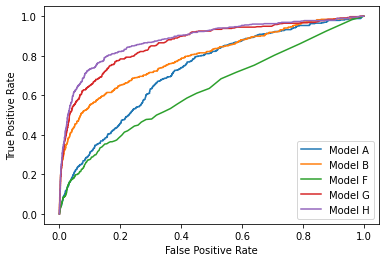

In [110]:
pyplot.plot(a_fpr, a_tpr, label='Model A')
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [111]:
plt.savefig(r"Z:\Output\Data tables\ROC\Mild_NPDR.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>

#### Moderate NPDR

In [112]:
prob_a = pd.read_csv(r"Z:\Data\A_prob_upd.csv")
prob_b = pd.read_csv(r"Z:\Data\probs-B_upd.csv")
prob_f = pd.read_csv(r"Z:\Data\prob-F_upd.csv")
prob_g = pd.read_csv(r"Z:\Data\prob - G_upd.csv")
prob_h = pd.read_csv(r"Z:\Data\prob-H_upd.csv")

In [113]:
prob_a = prob_a[['SEQN','Laterality', 'Mod_NPDR_prob']]
prob_a = prob_a.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mod_NPDR_prob')
prob_a = pd.merge(df, prob_a, on='SEQN')

prob_b = prob_b[['SEQN','Laterality', 'Mod_NPDR_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mod_NPDR_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')

prob_f = prob_f[['SEQN','Laterality', 'Mod_NPDR_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mod_NPDR_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')

prob_g = prob_g[['SEQN','Laterality', 'Mod_NPDR_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mod_NPDR_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')

prob_h = prob_h[['SEQN','Laterality', 'Mod_NPDR_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'Mod_NPDR_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')

In [114]:
prob_a['Worse'] = prob_a[['OD', 'OS']].max(axis=1)
prob_a = prob_a[['SEQN','RetLev', 'Worse']]

prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','RetLev', 'Worse']]

prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','RetLev', 'Worse']]

prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','RetLev', 'Worse']]

prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','RetLev', 'Worse']]

In [115]:
prob_a = prob_a.dropna()
prob_b = prob_b.dropna()
prob_f = prob_f.dropna()
prob_g = prob_g.dropna()
prob_h = prob_h.dropna()

print ("N_A: ", prob_a['SEQN'].nunique())
print ("N_B: ", prob_b['SEQN'].nunique())
print ("N_F: ", prob_f['SEQN'].nunique())
print ("N_G: ", prob_g['SEQN'].nunique())
print ("N_H: ", prob_h['SEQN'].nunique())

N_A:  5378
N_B:  5716
N_F:  5699
N_G:  5742
N_H:  5742


In [116]:
actual = prob_a['RetLev']
predicted = prob_a['Worse']
a_fpr, a_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=2)

actual = prob_b['RetLev']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=2)

actual = prob_f['RetLev']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=2)

actual = prob_g['RetLev']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=2)

actual = prob_h['RetLev']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=2)

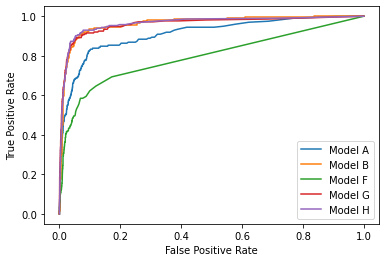

In [117]:
pyplot.plot(a_fpr, a_tpr, label='Model A')
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [118]:
plt.savefig(r"Z:\Output\Data tables\ROC\Moderate_NPDR.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>

#### Severe NPDR

In [119]:
prob_a = pd.read_csv(r"Z:\Data\A_prob_upd.csv")
prob_b = pd.read_csv(r"Z:\Data\probs-B_upd.csv")
prob_f = pd.read_csv(r"Z:\Data\prob-F_upd.csv")
prob_g = pd.read_csv(r"Z:\Data\prob - G_upd.csv")
prob_h = pd.read_csv(r"Z:\Data\prob-H_upd.csv")

prob_a = prob_a[['SEQN','Laterality', 'Sev_NPDR_prob']]
prob_a = prob_a.pivot(index = 'SEQN', columns = 'Laterality', values = 'Sev_NPDR_prob')
prob_a = pd.merge(df, prob_a, on='SEQN')

prob_b = prob_b[['SEQN','Laterality', 'Sev_NPDR_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'Sev_NPDR_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')

prob_f = prob_f[['SEQN','Laterality', 'Sev_NPDR_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'Sev_NPDR_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')

prob_g = prob_g[['SEQN','Laterality', 'Sev_NPDR_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'Sev_NPDR_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')

prob_h = prob_h[['SEQN','Laterality', 'Sev_NPDR_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'Sev_NPDR_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')

In [120]:
prob_a['Worse'] = prob_a[['OD', 'OS']].max(axis=1)
prob_a = prob_a[['SEQN','RetLev', 'Worse']]

prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','RetLev', 'Worse']]

prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','RetLev', 'Worse']]

prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','RetLev', 'Worse']]

prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','RetLev', 'Worse']]

In [121]:
prob_a = prob_a.dropna()
prob_b = prob_b.dropna()
prob_f = prob_f.dropna()
prob_g = prob_g.dropna()
prob_h = prob_h.dropna()

print ("N_A: ", prob_a['SEQN'].nunique())
print ("N_B: ", prob_b['SEQN'].nunique())
print ("N_F: ", prob_f['SEQN'].nunique())
print ("N_G: ", prob_g['SEQN'].nunique())
print ("N_H: ", prob_h['SEQN'].nunique())

N_A:  5378
N_B:  5716
N_F:  5699
N_G:  5742
N_H:  5742


In [122]:
actual = prob_a['RetLev']
predicted = prob_a['Worse']
a_fpr, a_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=3)

actual = prob_b['RetLev']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=3)

actual = prob_f['RetLev']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=3)

actual = prob_g['RetLev']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=3)

actual = prob_h['RetLev']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=3)

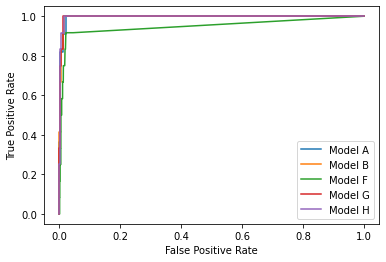

In [123]:
pyplot.plot(a_fpr, a_tpr, label='Model A')
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [124]:
plt.savefig(r"Z:\Output\Data tables\ROC\Severe_NPDR.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>

#### PDR

In [125]:
prob_a = pd.read_csv(r"Z:\Data\A_prob_upd.csv")
prob_b = pd.read_csv(r"Z:\Data\probs-B_upd.csv")
prob_f = pd.read_csv(r"Z:\Data\prob-F_upd.csv")
prob_g = pd.read_csv(r"Z:\Data\prob - G_upd.csv")
prob_h = pd.read_csv(r"Z:\Data\prob-H_upd.csv")

prob_a = prob_a[['SEQN','Laterality', 'PDR_prob']]
prob_a = prob_a.pivot(index = 'SEQN', columns = 'Laterality', values = 'PDR_prob')
prob_a = pd.merge(df, prob_a, on='SEQN')

prob_b = prob_b[['SEQN','Laterality', 'PDR_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'PDR_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')

prob_f = prob_f[['SEQN','Laterality', 'PDR_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'PDR_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')

prob_g = prob_g[['SEQN','Laterality', 'PDR_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'PDR_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')

prob_h = prob_h[['SEQN','Laterality', 'PDR_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'PDR_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')

In [126]:
prob_a['Worse'] = prob_a[['OD', 'OS']].max(axis=1)
prob_a = prob_a[['SEQN','RetLev', 'Worse']]

prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','RetLev', 'Worse']]

prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','RetLev', 'Worse']]

prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','RetLev', 'Worse']]

prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','RetLev', 'Worse']]

In [127]:
prob_a = prob_a.dropna()
prob_b = prob_b.dropna()
prob_f = prob_f.dropna()
prob_g = prob_g.dropna()
prob_h = prob_h.dropna()

print ("N_A: ", prob_a['SEQN'].nunique())
print ("N_B: ", prob_b['SEQN'].nunique())
print ("N_F: ", prob_f['SEQN'].nunique())
print ("N_G: ", prob_g['SEQN'].nunique())
print ("N_H: ", prob_h['SEQN'].nunique())

N_A:  5378
N_B:  5716
N_F:  5699
N_G:  5742
N_H:  5742


In [128]:
actual = prob_a['RetLev']
predicted = prob_a['Worse']
a_fpr, a_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=4)

actual = prob_b['RetLev']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=4)

actual = prob_f['RetLev']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=4)

actual = prob_g['RetLev']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=4)

actual = prob_h['RetLev']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=4)

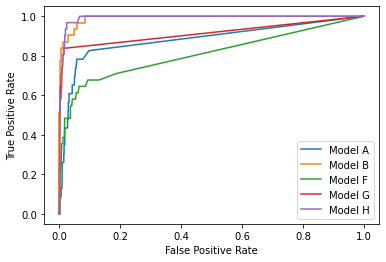

In [129]:
pyplot.plot(a_fpr, a_tpr, label='Model A')
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [130]:
plt.savefig(r"Z:\Output\Data tables\ROC\PDR.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>

#### Ungradable
*models b,d,e,f,g,h

In [131]:
prob_b = pd.read_csv(r"Z:\Data\probs-B_upd.csv")
prob_d = pd.read_csv(r"Z:\Data\prob-D_upd.csv")
prob_e = pd.read_csv(r"Z:\Data\prob-E_upd.csv")
prob_f = pd.read_csv(r"Z:\Data\prob-F_upd.csv")
prob_g = pd.read_csv(r"Z:\Data\prob - G_upd.csv")
prob_h = pd.read_csv(r"Z:\Data\prob-H_upd.csv")

prob_b = prob_b[['SEQN','Laterality', 'Ungrade_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'Ungrade_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')

prob_d = prob_d[['SEQN','Laterality', 'Ungrade_prob']]
prob_d = prob_d.pivot(index = 'SEQN', columns = 'Laterality', values = 'Ungrade_prob')
prob_d = pd.merge(df, prob_d, on='SEQN')

prob_e = prob_e[['SEQN','Laterality', 'Ungrade_prob']]
prob_e = prob_e.pivot(index = 'SEQN', columns = 'Laterality', values = 'Ungrade_prob')
prob_e = pd.merge(df, prob_e, on='SEQN')

prob_f = prob_f[['SEQN','Laterality', 'Ungrade_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'Ungrade_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')

prob_g = prob_g[['SEQN','Laterality', 'Ungrade_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'Ungrade_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')

prob_h = prob_h[['SEQN','Laterality', 'Ungrade_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'Ungrade_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')

In [132]:
prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','RetLev', 'Worse']]

prob_d['Worse'] = prob_d[['OD', 'OS']].max(axis=1)
prob_d = prob_d[['SEQN','RetLev', 'Worse']]

prob_e['Worse'] = prob_e[['OD', 'OS']].max(axis=1)
prob_e = prob_e[['SEQN','RetLev', 'Worse']]

prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','RetLev', 'Worse']]

prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','RetLev', 'Worse']]

prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','RetLev', 'Worse']]

In [133]:
prob_b = prob_b.dropna()
prob_d = prob_d.dropna()
prob_e = prob_e.dropna()
prob_f = prob_f.dropna()
prob_g = prob_g.dropna()
prob_h = prob_h.dropna()

print ("N_B: ", prob_b['SEQN'].nunique())
print ("N_D: ", prob_d['SEQN'].nunique())
print ("N_E: ", prob_e['SEQN'].nunique())
print ("N_F: ", prob_f['SEQN'].nunique())
print ("N_G: ", prob_g['SEQN'].nunique())
print ("N_H: ", prob_h['SEQN'].nunique())

N_B:  5742
N_D:  5134
N_E:  5134
N_F:  5740
N_G:  5742
N_H:  5742


In [134]:
actual = prob_b['RetLev']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=5)

actual = prob_d['RetLev']
predicted = prob_d['Worse']
d_fpr, d_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=5)

actual = prob_e['RetLev']
predicted = prob_e['Worse']
e_fpr, e_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=5)

actual = prob_f['RetLev']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=5)

actual = prob_g['RetLev']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=5)

actual = prob_h['RetLev']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=5)

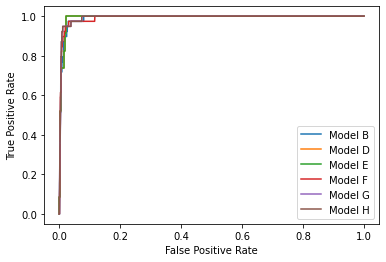

In [135]:
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(d_fpr, d_tpr, label='Model D')
pyplot.plot(e_fpr, e_tpr, label='Model E')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [136]:
plt.savefig(r"Z:\Output\Data tables\ROC\Ungrade.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>